In [37]:
import numpy as np
import pandas as pd
import SensoriMotorPrediction.globals as gl
import os
import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels.formula.api as smf
from scipy.stats import zscore

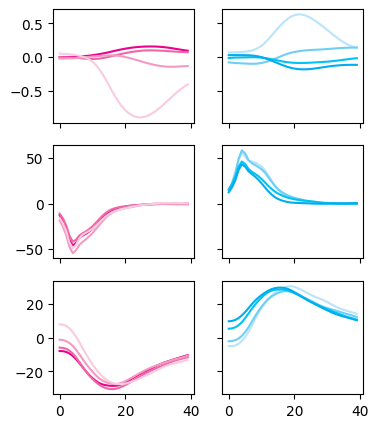

In [43]:
monkey = 'Malfoy'
roi = 'M1'
rec = 25

# load trial info
trial_info = pd.read_csv(os.path.join(gl.nhpDir, gl.recDir, monkey, f'trial_info-{rec}.tsv'), sep='\t')
idx = np.where((trial_info.isCatch == 0) & (trial_info.AdaptationBlock == 0))[0]
trial_info = trial_info.loc[idx].reset_index()
mapping_cond = {1: 1, 2: 8, 3: 3, 4: 6, 5: 2, 6: 5, 7: 4, 8: 7}
trial_info.cond = trial_info.cond.map(mapping_cond)

# load lfp
lfp = np.load(os.path.join(gl.nhpDir, gl.lfpDir, monkey, f'corrective_drive.beta-gamma.{roi}-{rec}.npy'))
#lfp[trial_info.pertDirection==1] *= -1

# load spike
spk = np.load(os.path.join(gl.nhpDir, gl.spkDir, monkey, f'corrective_drive.{roi}-{rec}.npy'))
#spk[trial_info.pertDirection==2] *= -1

# load kinematics
kin = np.load(os.path.join(gl.nhpDir, gl.behavDir, monkey, f'kin_aligned-{rec}.npy'))
kin = kin[gl.pertIdx:]
kin_centred = kin.copy()
kin_centred[:, trial_info.pertDirection==1] = kin_centred[:, trial_info.pertDirection==1] - kin_centred[:, trial_info.pertDirection==1].mean(axis=1, keepdims=True)
kin_centred[:, trial_info.pertDirection==2] = kin_centred[:, trial_info.pertDirection==2] - kin_centred[:, trial_info.pertDirection==2].mean(axis=1, keepdims=True)
#kin_centred[:, trial_info.pertDirection==1] *= -1

fig, axs = plt.subplots(3, 2, sharex=True, sharey='row', figsize=(4, 5))
color = list(gl.colour_mapping.values())[5:]

for c, cond in enumerate(np.sort(trial_info.cond.unique())):
    if cond<5:
        ax_c=axs[:, 0]
    else:
        ax_c=axs[:, 1]
    ax_c[0].plot(kin_centred[:, trial_info.cond==cond].mean(axis=1), color=color[c])
    ax_c[1].plot(lfp[trial_info.cond==cond].mean(axis=0), color=color[c])
    ax_c[2].plot(spk[trial_info.cond==cond].mean(axis=0), color=color[c])

#axs[2].set_xlim([gl.pertIdx, None])
#ax.legend()